In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# Load
df_q3 = pd.read_csv('q3_retail_promotions.csv')
df_q3['transaction_date'] = pd.to_datetime(df_q3['transaction_date'])

# Extract Features
df_q3['year'] = df_q3['transaction_date'].dt.year
df_q3['month'] = df_q3['transaction_date'].dt.month
df_q3['day_of_week'] = df_q3['transaction_date'].dt.dayofweek
df_q3['is_month_end'] = (df_q3['transaction_date'].dt.day >= 25).astype(int)

df_q3.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [2]:
# Sort by date (Strictly required for time-series data)
df_q3 = df_q3.sort_values('transaction_date')

# Split 80% train, 20% test
split_point = int(len(df_q3) * 0.8)
train = df_q3.iloc[:split_point]
test = df_q3.iloc[split_point:]

X_train = train.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train['items_sold']
X_test = test.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test['items_sold']

print(f"Data split at row {split_point}")

Data split at row 960


In [3]:
# Define column types
categorical_features = ['location_type', 'promotion_type', 'store_size']
numerical_features = ['year', 'month', 'day_of_week', 'is_month_end', 'is_weekend', 'is_festival', 'competition_density']

# Build the assembly line (Pipeline)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Random Forest Pipeline
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Report results
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")

RMSE: 31.11
MAE: 24.99


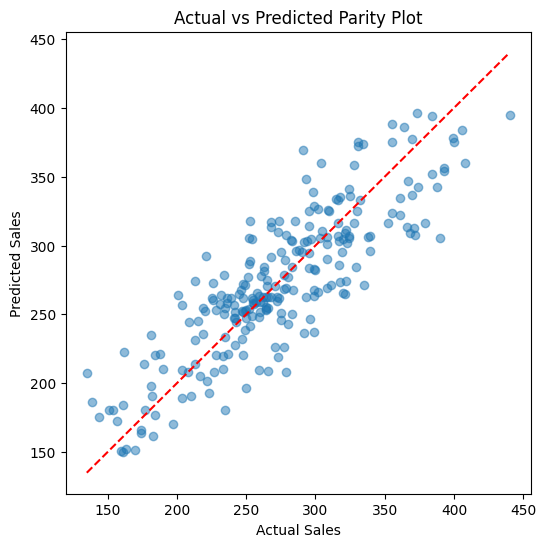

In [4]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Parity Plot')
plt.show()